## DANGCEM STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

dangcem=pd.read_csv('../stock_data/dangcem.csv') ## so it can be small letter. This is cool.
dangcem=dangcem.drop(columns=['high_price','low_price'])
dangcem.rename(columns={'trade_date':'date'},inplace=True)
dangcem['date']=pd.to_datetime(dangcem['date'])
dangcem['month']=dangcem['date'].dt.month
dangcem['quarter']=dangcem['date'].dt.quarter
dangcem['year']=dangcem['date'].dt.year

dangcem

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42778,DANGCEM,2017-01-03,173.99,173.99,19200,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43338,DANGCEM,2017-01-04,173.99,173.99,29100,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43448,DANGCEM,2017-01-05,167.02,167.02,191164,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43558,DANGCEM,2017-01-06,167.00,167.00,64437,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43648,DANGCEM,2017-01-09,169.00,169.00,401559,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298050,DANGCEM,2026-07-13,1047.00,1047.00,364352,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298488,DANGCEM,2026-07-14,1047.00,1047.00,919411,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298926,DANGCEM,2026-07-15,1047.00,1047.00,2505955,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299364,DANGCEM,2026-07-16,1047.00,1047.00,269517,2026-07-16T15:10:03.113936+00:00,7,3,2026


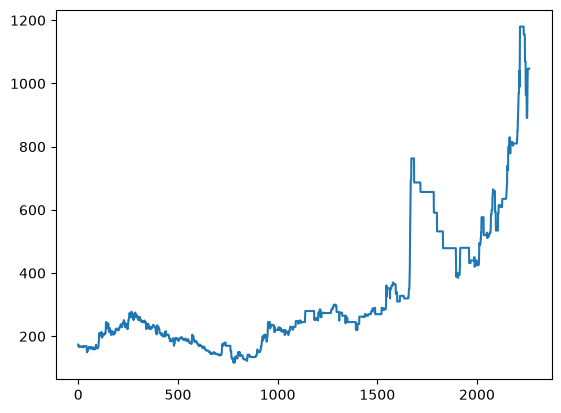

In [2]:
import matplotlib.pyplot as plt

plt.plot(dangcem['close_price'])
plt.show()

In [3]:
dangcem_end_month_df = (
    dangcem
    .sort_values("date")
    .groupby(dangcem["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

dangcem_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45348,DANGCEM,2017-01-31,166.00,166.00,62010,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47169,DANGCEM,2017-02-28,168.99,168.99,13849,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49285,DANGCEM,2017-03-31,165.00,165.00,22641,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51113,DANGCEM,2017-04-28,159.00,159.00,972037,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53035,DANGCEM,2017-05-31,175.00,175.00,1125522,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35286,DANGCEM,2026-03-31,810.00,810.00,472338,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281113,DANGCEM,2026-04-30,970.00,970.00,3269559,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284179,DANGCEM,2026-05-29,1180.00,1180.00,581274,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294108,DANGCEM,2026-06-30,963.00,963.00,765054,2026-06-30T15:10:03.08168+00:00,6,2,2026


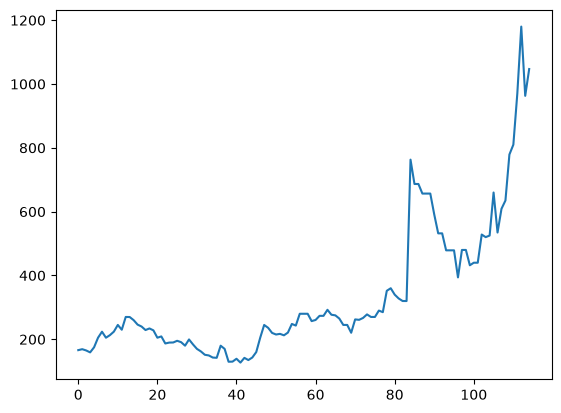

In [4]:
plt.plot(dangcem_end_month_df['close_price'])
plt.show()

In [5]:
dangcem_end_month_df['returns']=dangcem_end_month_df['close_price'].pct_change()*100
dangcem_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45348,DANGCEM,2017-01-31,166.00,166.00,62010,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47169,DANGCEM,2017-02-28,168.99,168.99,13849,2026-04-08T02:44:45.006295+00:00,2,1,2017,1.801205
2,49285,DANGCEM,2017-03-31,165.00,165.00,22641,2026-04-08T02:45:42.281198+00:00,3,1,2017,-2.361086
3,51113,DANGCEM,2017-04-28,159.00,159.00,972037,2026-04-08T02:51:55.619599+00:00,4,2,2017,-3.636364
4,53035,DANGCEM,2017-05-31,175.00,175.00,1125522,2026-04-08T02:52:57.421655+00:00,5,2,2017,10.062893
...,...,...,...,...,...,...,...,...,...,...,...
110,35286,DANGCEM,2026-03-31,810.00,810.00,472338,2026-03-31T15:00:02.085058+00:00,3,1,2026,3.979461
111,281113,DANGCEM,2026-04-30,970.00,970.00,3269559,2026-04-30T15:00:02.170664+00:00,4,2,2026,19.753086
112,284179,DANGCEM,2026-05-29,1180.00,1180.00,581274,2026-05-29T15:00:02.455558+00:00,5,2,2026,21.649485
113,294108,DANGCEM,2026-06-30,963.00,963.00,765054,2026-06-30T15:10:03.08168+00:00,6,2,2026,-18.389831


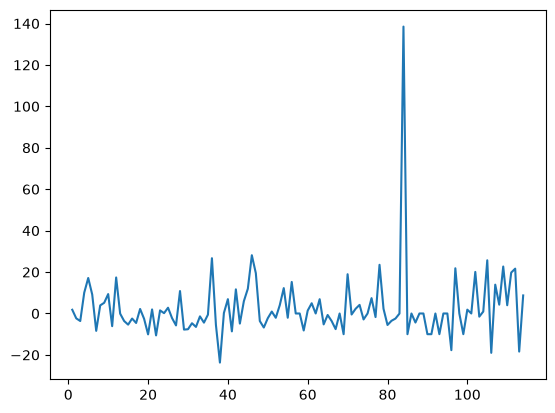

In [6]:
plt.plot(dangcem_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(dangcem_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-11.437895754165336), np.float64(6.2820789061413505e-21), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(853.4836893189465))
stationary


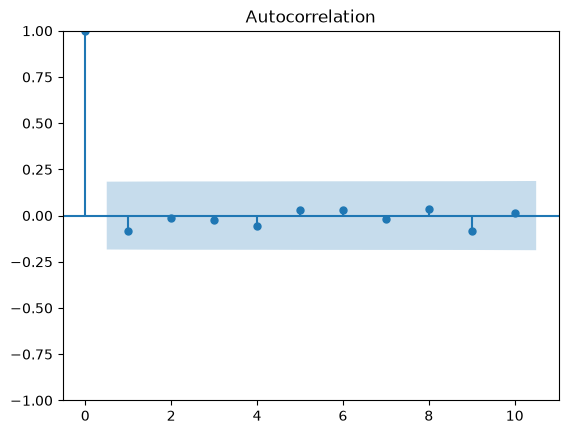

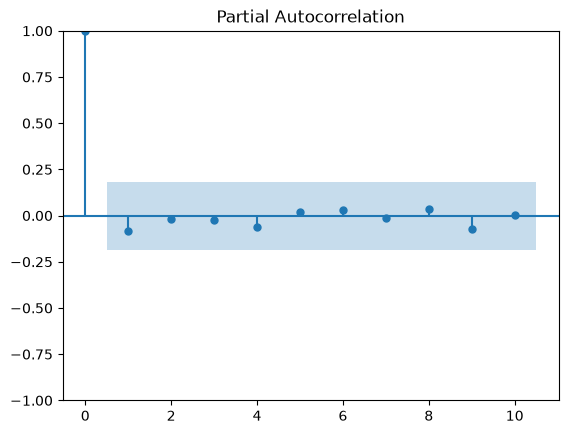

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(dangcem_end_month_df['returns'].dropna(), lags=10)
plot_pacf(dangcem_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=dangcem_end_month_df['close_price'][:-10]
test=dangcem_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -16.285186177343512]
[0, 0, 0, 0, 0, 1, -14.74617881940986]
[0, 0, 0, 0, 0, 2, -10.926760743712016]
[0, 0, 0, 0, 1, 0, -3.1028383726022026]
[0, 0, 0, 0, 1, 1, -2.812436364553042]
[0, 0, 0, 0, 1, 2, -0.5787001411430599]
[0, 0, 0, 0, 2, 0, -7.042217375538913]
[0, 0, 0, 0, 2, 1, -2.53193087941915]
[0, 0, 0, 0, 2, 2, -0.05182656603419744]
[0, 0, 0, 1, 0, 0, -3.8127865536880625]
[0, 0, 0, 1, 0, 1, -3.250887666624725]
[0, 0, 0, 1, 0, 2, -0.9149596398748208]
[0, 0, 0, 1, 1, 0, -2.247322683200169]
[0, 0, 0, 1, 1, 1, -2.157023230719959]
[0, 0, 0, 1, 1, 2, -0.6877515389591466]
[0, 0, 0, 1, 2, 0, -0.20306167674583664]
[0, 0, 0, 1, 2, 1, -0.4164928907448908]
[0, 0, 0, 1, 2, 2, -0.0839590698515178]
[0, 0, 0, 2, 0, 0, -2.746742743583494]
[0, 0, 0, 2, 0, 1, -2.708441022083595]
[0, 0, 0, 2, 0, 2, -0.8929288193748199]
[0, 0, 0, 2, 1, 0, -1.9493450661577079]
[0, 0, 0, 2, 1, 1, -2.1713943827722635]
[0, 0, 0, 2, 1, 2, -0.8667853607372518]
[0, 0, 0, 2, 2, 0, -0.15976642161097887]
[0, 0, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
458,1,2,1,2,2,2,-8.326623e+08
65,0,0,2,1,0,2,-1.999223e+08
643,2,1,2,2,2,2,-2.666159e+05
0,0,0,0,0,0,0,-1.628519e+01
45,0,0,1,2,0,0,-1.628519e+01
...,...,...,...,...,...,...,...
669,2,2,0,2,2,1,4.837030e-01
183,0,2,0,2,1,0,5.124346e-01
647,2,2,0,0,1,0,6.347839e-01
659,2,2,0,1,2,0,6.461956e-01


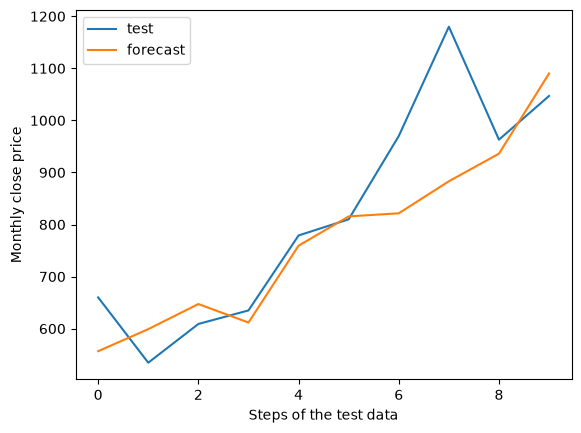

r2_score:  0.6841365201810204
rmse:  114.02759411502663
description:  count     115.000000
mean      334.566261
std       212.946091
min       127.000000
25%       202.245000
50%       260.000000
75%       436.000000
max      1180.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=dangcem_end_month_df['close_price'][:-10]
y_test=dangcem_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(0,2,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', dangcem_end_month_df.close_price.describe())

This is really good.